# Project 3 – Visualize
### CIVE 202 – Engineering Problem-Solving with Computers
**Client:** Federal Highway Administration (FHWA)  
**Team:** Michael Albracht, Mina Awad, Nick Meier, Levi Woockman  
**Due:** March 31, 2026

---
This notebook produces all required visualizations and the IDM simulation for the FHWA transportation planning group.  
It is organized into four sections:
1. Setup & Data Loading
2. NHTS Visualizations (Bar Chart, Histogram, Boxplot)
3. NGSIM Time-Series Visualizations
4. IDM Simulation


## Section 1 – Setup & Data Loading

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent, professional visual style for all plots
sns.set_style('whitegrid')
sns.set_palette('deep')


In [2]:
# ── Load NHTS dataset ──────────────────────────────────────────────────────
# The National Household Travel Survey (NHTS) contains vehicle-level records
# capturing vehicle type, household size, fuel type, and other attributes.

nhts_data = pd.read_csv('NHTS(in).csv')

print(f"NHTS dataset loaded: {nhts_data.shape[0]} rows, {nhts_data.shape[1]} columns")
nhts_data.head()


NHTS dataset loaded: 14684 rows, 23 columns


,household_id,census_division,census_region,driver_count,household_income,household_size,household_workers,home_type,household_location,number_adults_household,...,urban,vehicle_type,hybrid,make,vehicle_age,vehicle_commercial,vehicle_delivery,vehicle_rideshare,fuel_type,vehicle_year
0,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,7,No,NaN,NaN,Gas,2015
1,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,3,No,NaN,NaN,Gas,2019
2,9000013016,New England,Northeast,2,"$75,000 to $99,999",2,2,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Toyota,11,No,NaN,NaN,Gas,2011
3,9000013039,New England,Northeast,2,"$75,000 to $99,999",4,1,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Nissan/Datsun,7,No,NaN,NaN,Gas,2015
4,9000013041,New England,Northeast,1,"$175,000 or more",1,1,"Townhome, Condo",Urban,1,...,In an urban area,Automobile/car/stationwagon,No,BMV,8,No,NaN,NaN,Gas,2014


In [3]:
# ── Inspect NHTS columns and data types ───────────────────────────────────
print("Column names and data types:")
print(nhts_data.dtypes)


Column names and data types:
household_id                int64
census_division            object
census_region              object
driver_count                int64
household_income           object
household_size              int64
household_workers           int64
home_type                  object
household_location         object
number_adults_household     int64
vehicles_per_household      int64
travel_date                 int64
travel_day                 object
urban                      object
vehicle_type               object
hybrid                     object
make                       object
vehicle_age                 int64
vehicle_commercial         object
vehicle_delivery           object
vehicle_rideshare          object
fuel_type                  object
vehicle_year                int64
dtype: object


In [4]:
# ── Descriptive statistics for NHTS ───────────────────────────────────────
# .describe() provides count, mean, std, min, quartiles, and max
# for all numeric columns – useful for understanding scale and range

nhts_data.describe()


,household_id,driver_count,household_size,household_workers,number_adults_household,vehicles_per_household,travel_date,vehicle_age,vehicle_year
count,1.468400e+04,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000
mean,9.000113e+09,2.014165,2.558090,1.179447,2.061223,2.534323,202211.722623,10.174271,2011.866658
std,5.936829e+04,0.814926,1.333751,0.984043,0.812286,1.436046,20.578951,7.959353,8.009252
min,9.000013e+09,0.000000,1.000000,0.000000,1.000000,1.000000,202201.000000,1.000000,1982.000000
25%,9.000057e+09,2.000000,2.000000,0.000000,2.000000,2.000000,202204.000000,4.000000,2007.000000
50%,9.000107e+09,2.000000,2.000000,1.000000,2.000000,2.000000,202208.000000,8.000000,2014.000000
75%,9.000166e+09,2.000000,3.000000,2.000000,2.000000,3.000000,202211.000000,15.000000,2018.000000
max,9.000218e+09,7.000000,10.000000,6.000000,8.000000,17.000000,202301.000000,40.000000,2023.000000


In [5]:
# ── Check for missing values in NHTS ──────────────────────────────────────
# Missing values can cause errors or misleading graphs; identify them early

nhts_data.isnull().sum()


household_id                   0
census_division                0
census_region                  0
driver_count                   0
household_income               0
household_size                 0
household_workers              0
home_type                      0
household_location             0
number_adults_household        0
vehicles_per_household         0
travel_date                    0
travel_day                     0
urban                          0
vehicle_type                   0
hybrid                         0
make                         116
vehicle_age                    0
vehicle_commercial            39
vehicle_delivery           13491
vehicle_rideshare          13487
fuel_type                     32
vehicle_year                   0
dtype: int64

In [22]:
# ── Value counts for key NHTS categorical variables ───────────────────────
# vehicle_type  : categories of vehicles in the survey
# household_size: number of people per household

print("vehicle_type value counts")
print(nhts_data['vehicle_type'].value_counts())

print("\n=== household_size value counts ===")
print(nhts_data['household_size'].value_counts().sort_index())


vehicle_type value counts
vehicle_type
Automobile/car/stationwagon            6382
SUV (Santa Fe, Tahoe, Jeep, etc.)      4562
Pickup Truck                           2393
Van (Minivan/Cargo/Passenger)           671
Motorcycle/Moped                        430
Recreational vehicle (RV)/Motorhome     112
Other truck                              81
Something else                           53
Name: count, dtype: int64

=== household_size value counts ===
household_size
1     2557
2     6714
3     2190
4     1870
5      884
6      299
7       91
8       45
9       23
10      11
Name: count, dtype: int64


In [7]:
# ── Load NGSIM dataset ─────────────────────────────────────────────────────
# The Next Generation Simulation (NGSIM) dataset contains time-step records
# for leader-follower vehicle pairs sampled at 0.1-second intervals.

ngsim_data = pd.read_csv('NGSIM(in).csv')

print(f"NGSIM dataset loaded: {ngsim_data.shape[0]} rows, {ngsim_data.shape[1]} columns")
ngsim_data.head()


NGSIM dataset loaded: 8166 rows, 8 columns


,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
0,0.1,26.654,0.0000,14.054,14.484,1.09730,-3.048000e-02,1
1,0.2,28.060,1.4484,14.164,14.481,-1.00580,-3.048000e-02,1
2,0.3,29.476,2.8965,14.063,14.478,-2.28600,6.096000e-02,1
3,0.4,30.882,4.3443,13.835,14.484,-0.88392,-3.048000e-02,1
4,0.5,32.266,5.7927,13.746,14.481,0.85344,1.780000e-13,1


---
## Section 2 – NHTS Visualizations

**Variables used:**
- `vehicle_type` – Classification of each household vehicle (Automobile, SUV, Pickup Truck, Van, etc.)
- `household_size` – Number of members in the household (1–10)

Three plots are produced:
1. **Grouped Bar Chart** – Vehicle type proportions across household sizes
2. **Histogram** – Frequency distribution of household size
3. **Boxplot** – Distribution of household size within each vehicle type


### Plot 1 – Grouped Bar Chart
**Purpose:** Compare the proportion of vehicle types across different household sizes.  
A grouped bar chart places bars side-by-side for each household size, making category
comparisons straightforward for the transportation planning group.


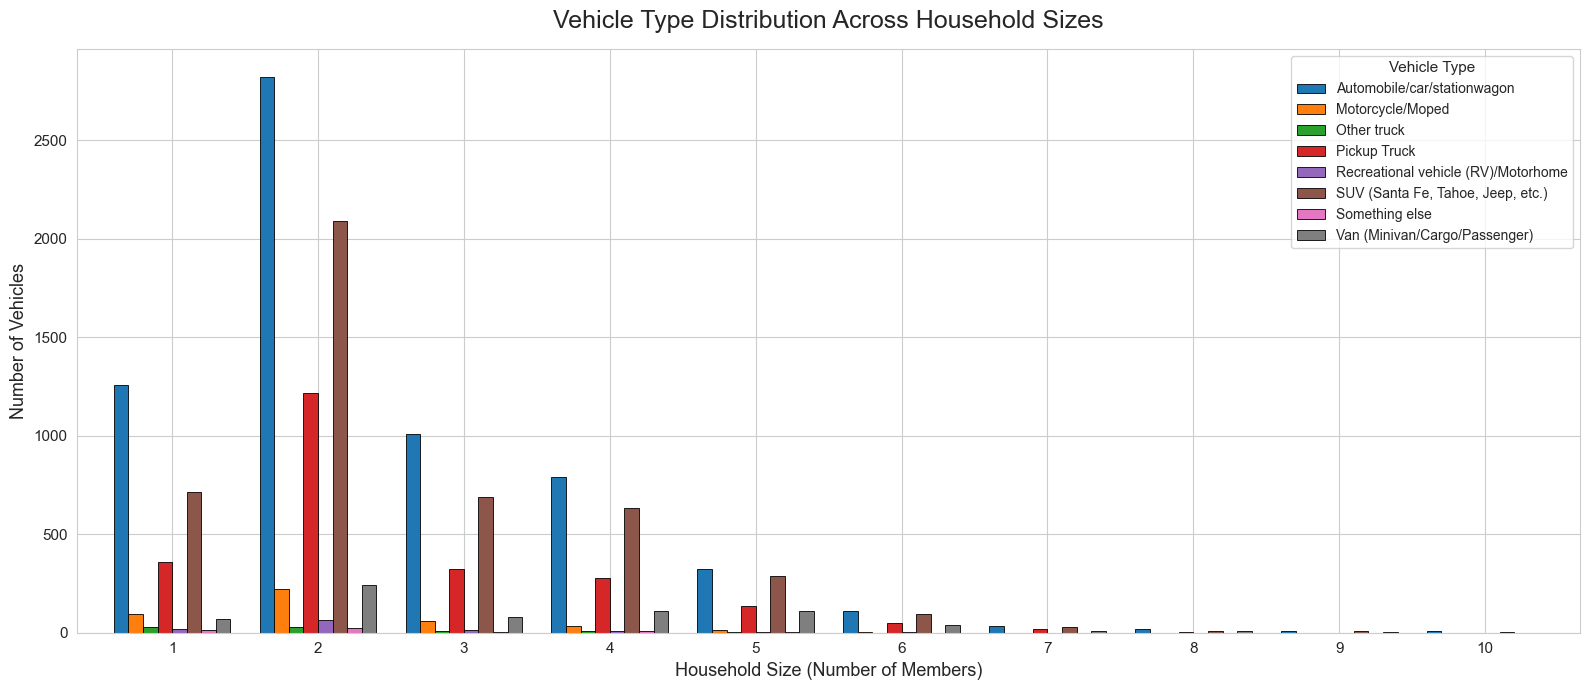

In [27]:
# ── Plot 1: Grouped Bar Chart – Vehicle Type by Household Size ─────────────
# Step 1: Drop rows where vehicle_type or household_size is missing
nhts_clean = nhts_data.dropna(subset=['vehicle_type', 'household_size'])

# Step 2: Group data by household_size and vehicle_type, count occurrences,
#         then unstack vehicle_type into columns for grouped plotting
grouped = (nhts_clean
           .groupby(['household_size', 'vehicle_type'])
           .size()
           .unstack(fill_value=0))

# Step 3: Create figure
fig, ax = plt.subplots(figsize=(16, 7))

# Step 4: Plot grouped bar chart using a custom seaborn color palette
# tab10 gives 10 distinct colors – ideal for categorical comparisons
colors = sns.color_palette('tab10', n_colors=grouped.shape[1])
grouped.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.6, width=0.8)

# Step 5: Customization – font sizes, rotation, legend placement
ax.set_title('Vehicle Type Distribution Across Household Sizes',
             fontsize=18, pad=15)
ax.set_xlabel('Household Size (Number of Members)', fontsize=13)
ax.set_ylabel('Number of Vehicles', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.tick_params(axis='y', labelsize=11)

# Move legend outside the plot area to avoid obscuring bars
ax.legend(title='Vehicle Type', title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()


### Plot 2 – Histogram
**Purpose:** Show the frequency distribution of household size across all NHTS records.  
A histogram reveals whether households in the survey are predominantly small or large,
which is relevant for trip generation and vehicle ownership forecasting.


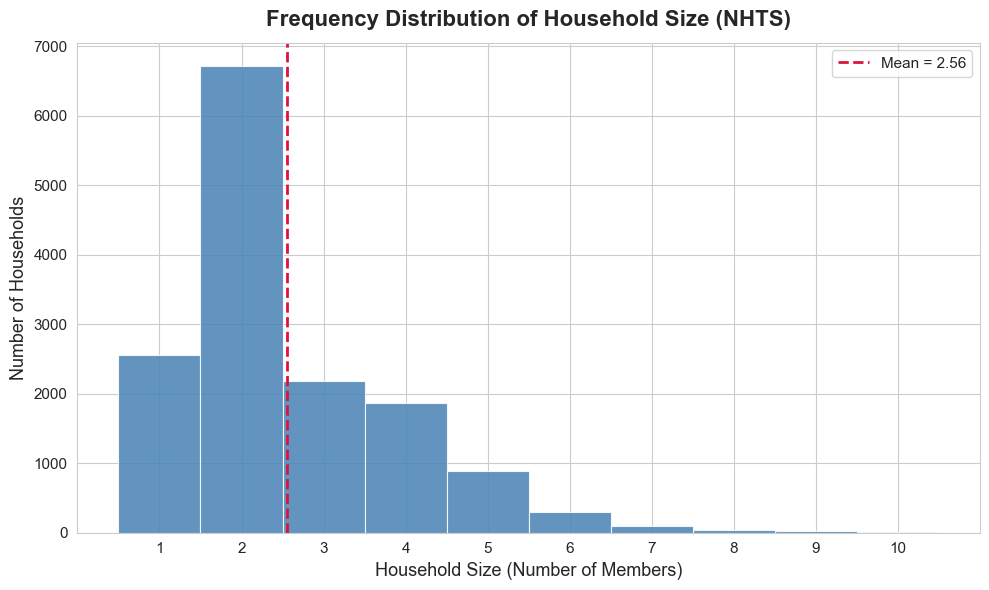

In [28]:
# ── Plot 2: Histogram – Distribution of Household Size ────────────────────
# Step 1: Drop missing household_size values
hhsize = nhts_data['household_size'].dropna()

# Step 2: Determine bin edges aligned with integer household sizes
bins = np.arange(hhsize.min() - 0.5, hhsize.max() + 1.5, 1)

# Step 3: Create figure
plt.figure(figsize=(10, 6))

# Step 4: Plot histogram with custom seaborn styling
# alpha controls transparency so the edgecolor is visible
plt.hist(hhsize, bins=bins, color='steelblue', edgecolor='white',
         linewidth=0.8, alpha=0.85)

# Step 5: Add a vertical dashed line at the mean for quick reference
mean_hhsize = hhsize.mean()
plt.axvline(mean_hhsize, color='crimson', linestyle='--', linewidth=2,
            label=f'Mean = {mean_hhsize:.2f}')

# Step 6: Labels, title, legend, and tick customization
plt.title('Frequency Distribution of Household Size (NHTS)',
          fontsize=16, fontweight='bold', pad=12)
plt.xlabel('Household Size (Number of Members)', fontsize=13)
plt.ylabel('Number of Households', fontsize=13)
plt.xticks(range(int(hhsize.min()), int(hhsize.max()) + 1), fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


### Plot 3 – Boxplot
**Purpose:** Display the distribution of household size within each vehicle type category.  
The boxplot reveals median values, interquartile ranges, and outliers, showing whether
certain vehicle types are consistently found in larger or smaller households.



C:\Users\micha\AppData\Local\Temp\ipykernel_2720\3669072879.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)


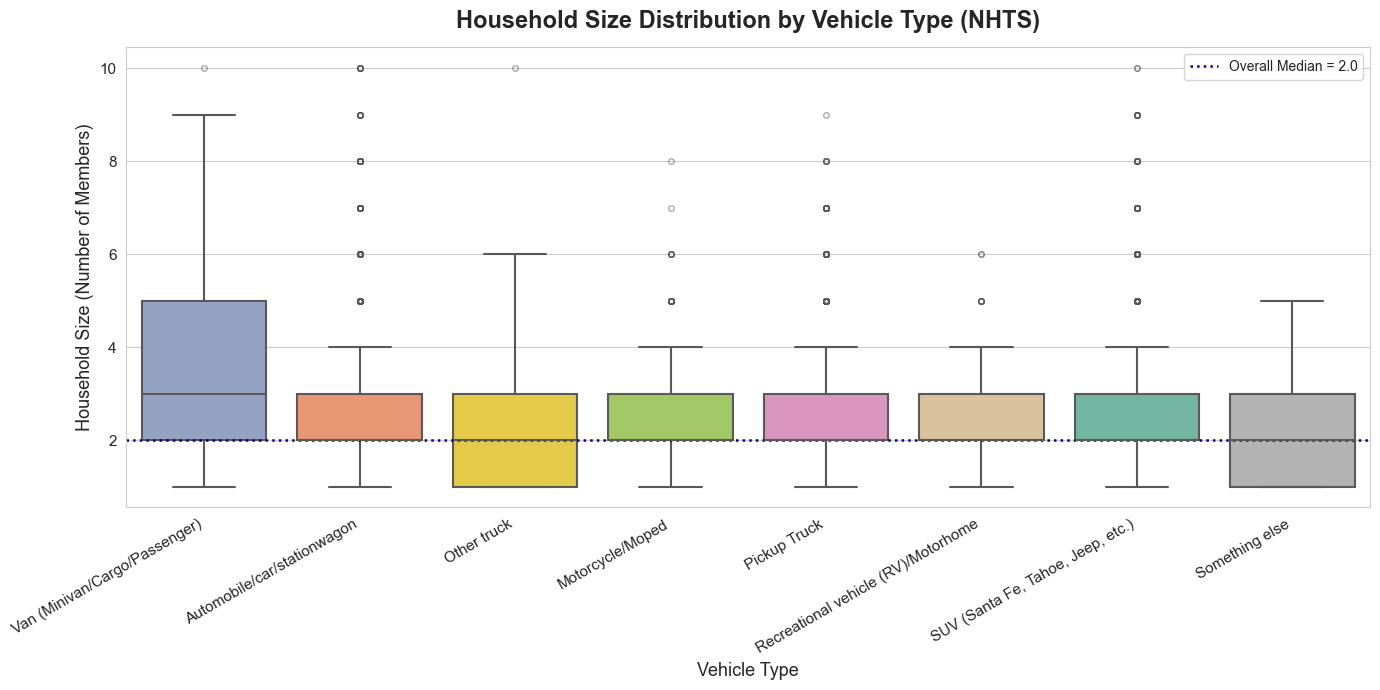

In [29]:
# ── Plot 3: Boxplot – Household Size by Vehicle Type ──────────────────────
# This plot demonstrates seaborn customization (palette, font sizes, tick rotation)

# Step 1: Drop rows with missing values in either variable
nhts_box = nhts_data.dropna(subset=['vehicle_type', 'household_size'])

# Step 2: Order categories by median household_size for cleaner presentation
order = (nhts_box.groupby('vehicle_type')['household_size']
         .median()
         .sort_values(ascending=False)
         .index)

# Step 3: Create figure
plt.figure(figsize=(14, 7))

# Step 4: seaborn boxplot with custom palette and hue for color coding
# 'Set2' is a colorblind-friendly palette
ax = sns.boxplot(data=nhts_box, x='vehicle_type', y='household_size',
                 order=order, palette='Set2', hue='vehicle_type',
                 linewidth=1.5, flierprops=dict(marker='o', markersize=4,
                                                alpha=0.5))

# Step 5: Advanced customization
ax.set_title('Household Size Distribution by Vehicle Type (NHTS)',
             fontsize=17, fontweight='bold', pad=14)
ax.set_xlabel('Vehicle Type', fontsize=13)
ax.set_ylabel('Household Size (Number of Members)', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)
ax.tick_params(axis='y', labelsize=11)

# Add a horizontal reference line at the overall median
overall_median = nhts_box['household_size'].median()
ax.axhline(overall_median, color='navy', linestyle=':', linewidth=1.8,
           label=f'Overall Median = {overall_median:.1f}')
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()


---
## Section 3 – NGSIM Time-Series Visualizations

**Variables used:**
- `trajectory_number` – Identifier for each leader-follower vehicle pair
- `Time` – Time in seconds (sampled at 0.1 s intervals)
- `leader_position(m)` – Longitudinal position of the lead vehicle
- `follower_speed(m/s)` – Speed of the following vehicle
- `leader_acc(m/s^2)` – Acceleration of the lead vehicle
- `follower_acc(m/s^2)` – Observed acceleration of the following vehicle

**Trajectory selected: #5** (different from Dr. Lane's trajectory #9)


In [12]:
# ── Select trajectory #5 and create data subset ───────────────────────────
TRAJECTORY = 5

data_subset = (ngsim_data[ngsim_data['trajectory_number'] == TRAJECTORY]
               .reset_index(drop=True))

print(f"Trajectory {TRAJECTORY}: {len(data_subset)} time steps")
print(f"Time range: {data_subset['Time'].min():.1f}s – {data_subset['Time'].max():.1f}s")
data_subset.head()


Trajectory 5: 401 time steps
Time range: 0.1s – 40.1s


,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
0,0.1,33.911,0.0000,14.307,13.719,-2.25550,-0.03048,5
1,0.2,35.342,1.3719,14.082,13.716,-0.91440,0.03048,5
2,0.3,36.750,2.7435,13.990,13.719,1.06680,-0.03048,5
3,0.4,38.149,4.1154,14.097,13.716,1.03630,-4.26720,5
4,0.5,39.559,5.4870,14.201,13.289,-0.88392,2.43840,5


### Time-Series Plot 1 – Leader Position & Follower Speed vs. Time
**Purpose:** Examine how the follower vehicle's speed responds to the evolving
position of the lead vehicle over the duration of the trajectory.  
Plotting both on the same time axis using a dual y-axis reveals lag effects
and the follower's reaction to leader deceleration events.


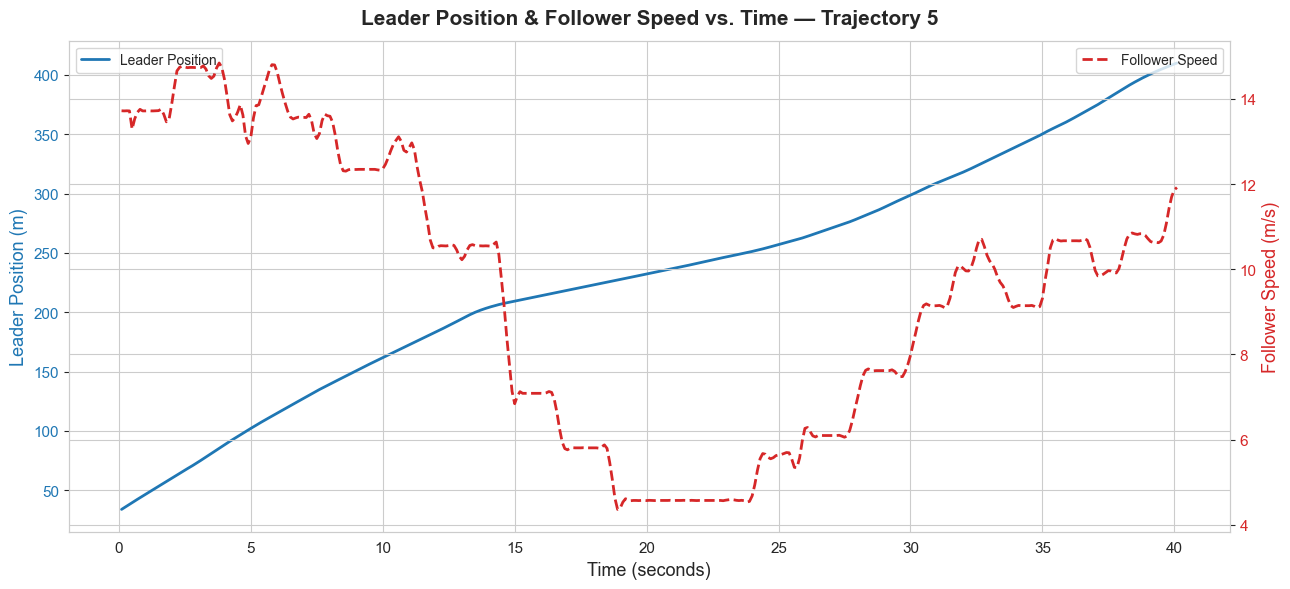

In [39]:
# ── Time-Series Plot 1: Leader Position & Follower Speed vs. Time ──────────
# Dual y-axis plot: left axis = leader position, right axis = follower speed

time  = data_subset['Time'].values
l_pos = data_subset['leader_position(m)'].values
f_spd = data_subset['follower_speed(m/s)'].values

fig, ax1 = plt.subplots(figsize=(13, 6))

# Left y-axis: leader position
ax1.set_xlabel('Time (seconds)', fontsize=13)
ax1.set_ylabel('Leader Position (m)', color=color_pos, fontsize=13)
ax1.plot(time, l_pos, color=color_pos, linewidth=2.0, label='Leader Position')
ax1.tick_params(axis='y', labelcolor=color_pos, labelsize=11)
ax1.tick_params(axis='x', labelsize=11)

# Right y-axis: follower speed
ax2 = ax1.twinx()
ax2.set_ylabel('Follower Speed (m/s)', color=color_spd, fontsize=13)
ax2.plot(time, f_spd, color=color_spd, linewidth=2.0, linestyle='--',
         label='Follower Speed')
ax2.tick_params(axis='y', labelcolor=color_spd, labelsize=11)

# Combined legend
ax1.legend()
ax2.legend()

plt.title(f'Leader Position & Follower Speed vs. Time — Trajectory {TRAJECTORY}',
          fontsize=15, fontweight='bold', pad=12)
fig.tight_layout()
plt.show()

### Time-Series Plot 2 – Leader & Follower Acceleration vs. Time
**Purpose:** Visualize the acceleration profiles of both vehicles over time.  
This plot establishes the observed baseline that the IDM simulation (Section 4)
will be compared against.


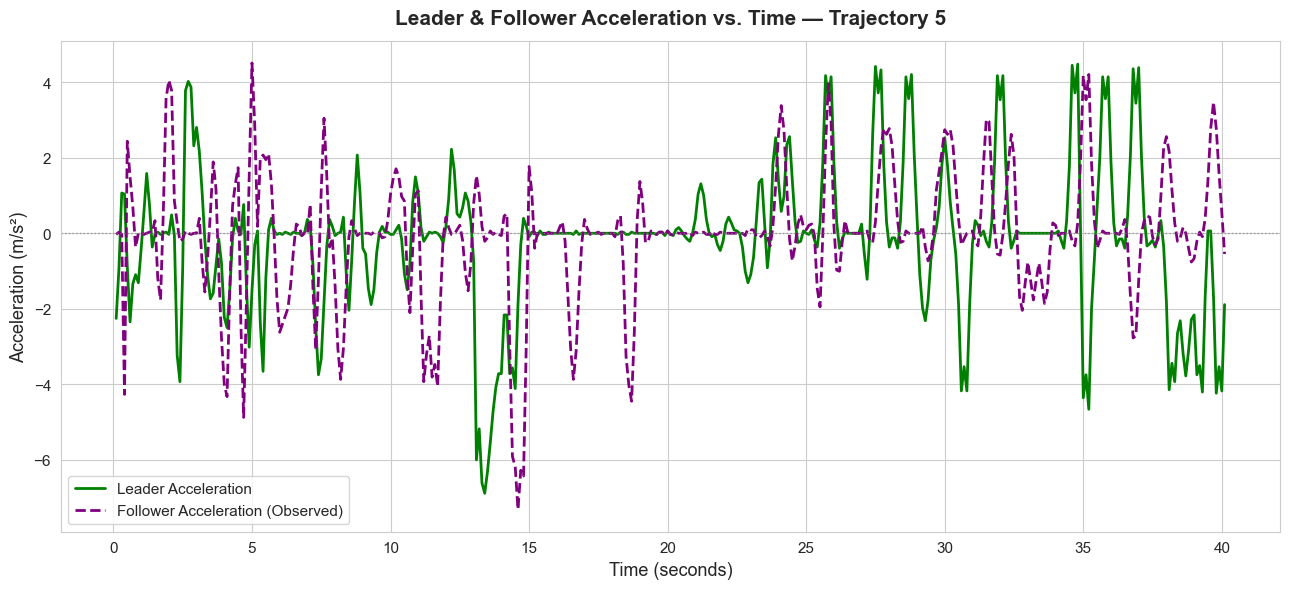

In [41]:
# ── Time-Series Plot 2: Leader & Follower Acceleration vs. Time ────────────
l_acc = data_subset['leader_acc(m/s^2)'].values
f_acc = data_subset['follower_acc(m/s^2)'].values

plt.figure(figsize=(13, 6))

plt.plot(time, l_acc, color='green', linewidth=2.0, label='Leader Acceleration')
plt.plot(time, f_acc, color='purple', linewidth=2.0, linestyle='--',
         label='Follower Acceleration (Observed)')

# Zero-acceleration reference line
plt.axhline(0, color='gray', linewidth=1.0, linestyle=':', alpha=0.7)

plt.title(f'Leader & Follower Acceleration vs. Time — Trajectory {TRAJECTORY}',
          fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Time (seconds)', fontsize=13)
plt.ylabel('Acceleration (m/s²)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


---
## Section 4 – Intelligent Driver Model (IDM) Simulation

The **Intelligent Driver Model (IDM)** (Treiber, Hennecke & Helbing, 2000) computes
follower acceleration as:

$$\frac{dv}{dt} = a \left[1 - \left(\frac{v}{v_0}\right)^\delta - \left(\frac{s^*(v, \Delta v)}{s}\right)^2\right]$$

Where the desired minimum gap $s^*$ is:

$$s^*(v, \Delta v) = s_0 + v \cdot T + \frac{v \cdot \Delta v}{2\sqrt{a \cdot b}}$$

| Parameter | Symbol | Description | Value Used |
|-----------|--------|-------------|------------|
| Desired velocity | $v_0$ | Free-flow target speed | 30 m/s |
| Minimum spacing | $s_0$ | Minimum gap at standstill | 2 m |
| Desired time headway | $T$ | Target time gap to leader | 1.5 s |
| Maximum acceleration | $a$ | Comfortable acceleration | 1.0 m/s² |
| Comfortable deceleration | $b$ | Comfortable braking | 1.5 m/s² |
| Acceleration exponent | $\delta$ | Speed-dependence exponent | 4 |


In [15]:
# ── Define the IDM acceleration function ──────────────────────────────────
# Inputs:
#   v        : follower speed (m/s)
#   s        : gap distance between leader and follower (m)
#   delta_v  : speed difference = follower speed − leader speed (m/s)
#   v0       : desired velocity (m/s)
#   s0       : minimum spacing (m)
#   T        : desired time headway (s)
#   a        : maximum acceleration (m/s²)
#   b        : comfortable deceleration (m/s²)
#   delta    : acceleration exponent
# Output:
#   acceleration (m/s²) of the follower vehicle

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Compute the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    # Ensure s_star is never less than minimum spacing (physical constraint)
    s_star = max(s_star, s0)
    
    # Step 2: Apply the IDM acceleration equation
    acceleration = a * (1 - (v / v0) ** delta - (s_star / s) ** 2)
    
    return acceleration

print("IDM function defined.")


IDM function defined.


In [16]:
# ── Quick sanity check of the IDM function ─────────────────────────────────
# A follower at 20 m/s, gap of 25 m, approaching leader at 2 m/s
# Expected: negative acceleration (deceleration) since follower is closing in

v0, s0, T, a_param, b, delta = 30, 2, 1.5, 1.0, 1.5, 4

test_acc = idm_acceleration(20, 25, 2, v0, s0, T, a_param, b, delta)
print(f"Test IDM acceleration: {test_acc:.4f} m/s²")
print("(Negative = deceleration — correct, the follower is closing on the leader)")


Test IDM acceleration: -2.9348 m/s²
(Negative = deceleration — correct, the follower is closing on the leader)


In [17]:
# ── Initialize the simulation using trajectory #5 ─────────────────────────
# Extract leader trajectory from NGSIM data as simulation input
time_data       = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed    = data_subset['leader_speed(m/s)'].values

dt      = 0.1          # time step (seconds) — matches NGSIM sampling rate
n_steps = len(time_data)

# Pre-allocate arrays for simulated follower state
sim_position = np.zeros(n_steps)
sim_speed    = np.zeros(n_steps)
sim_acc      = np.zeros(n_steps)

# Initialize follower at the real NGSIM starting state
sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0]    = data_subset['follower_speed(m/s)'].values[0]

print(f"Simulation initialized over {n_steps} time steps ({n_steps * dt:.1f} seconds)")
print(f"Initial follower position: {sim_position[0]:.2f} m")
print(f"Initial follower speed:    {sim_speed[0]:.2f} m/s")


Simulation initialized over 401 time steps (40.1 seconds)
Initial follower position: 0.00 m
Initial follower speed:    13.72 m/s


In [18]:
# ── Run the IDM simulation using Euler's method ────────────────────────────
# At each time step i:
#   1. Compute gap  = leader_position[i] − sim_position[i]
#   2. Compute delta_v = sim_speed[i] − leader_speed[i]
#   3. Compute IDM acceleration
#   4. Update speed:    sim_speed[i+1]    = sim_speed[i]    + acc * dt
#   5. Update position: sim_position[i+1] = sim_position[i] + speed * dt

# IDM parameters (same as sanity check above)
v0      = 30    # desired velocity (m/s)
s0      = 2     # minimum spacing (m)
T       = 1.5   # desired time headway (s)
a_param = 1.0   # maximum acceleration (m/s²)
b       = 1.5   # comfortable deceleration (m/s²)
delta   = 4     # acceleration exponent

for i in range(n_steps - 1):
    # Gap: ensure it is at least 0.1 m to prevent division by zero
    gap     = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]

    # IDM acceleration at this time step
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v,
                                  v0, s0, T, a_param, b, delta)

    # Euler update (speed cannot go negative)
    sim_speed[i + 1]    = max(sim_speed[i] + sim_acc[i] * dt, 0)
    sim_position[i + 1] = sim_position[i] + sim_speed[i] * dt

# Fill last acceleration value
sim_acc[-1] = sim_acc[-2]

print("IDM simulation complete!")
print(f"Simulated speed range: {sim_speed.min():.2f} – {sim_speed.max():.2f} m/s")
print(f"Simulated acc range:   {sim_acc.min():.2f} – {sim_acc.max():.2f} m/s²")


IDM simulation complete!
Simulated speed range: 4.59 – 14.96 m/s
Simulated acc range:   -2.72 – 0.93 m/s²


### IDM Simulation Plot – Acceleration Comparison
**Purpose (required by client):** Compare three acceleration traces on a single plot:
1. Leader acceleration (NGSIM observed)
2. Follower acceleration (NGSIM observed)
3. Follower acceleration (IDM simulated)

This reveals how closely the IDM model replicates real car-following behavior.


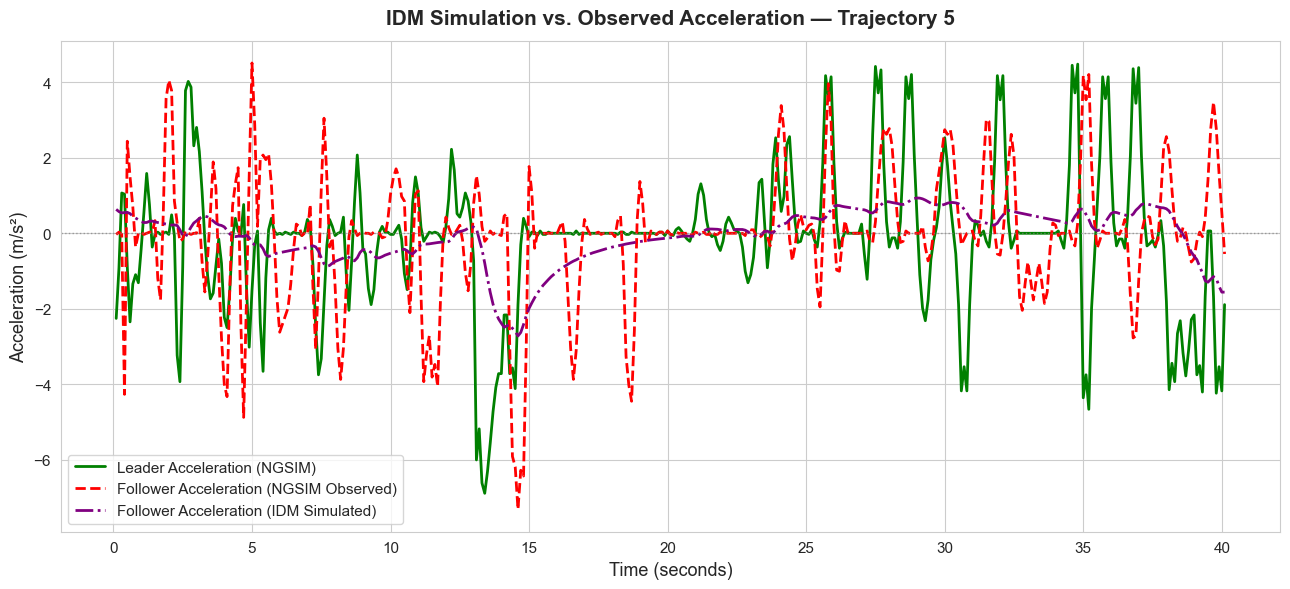

In [46]:
# ── IDM Simulation Plot: Acceleration Comparison ──────────────────────────
# Three lines: leader (NGSIM), follower (NGSIM observed), follower (IDM simulated)

l_acc = data_subset['leader_acc(m/s^2)'].values
f_acc = data_subset['follower_acc(m/s^2)'].values

plt.figure(figsize=(13, 6))

plt.plot(time_data, l_acc,
         color='green', linewidth=2.0, label='Leader Acceleration (NGSIM)')

plt.plot(time_data, f_acc,
         color='red', linewidth=2.0, linestyle='--',
         label='Follower Acceleration (NGSIM Observed)')

plt.plot(time_data, sim_acc,
         color='purple', linewidth=2.0, linestyle='-.',
         label='Follower Acceleration (IDM Simulated)')

# Zero reference line
plt.axhline(0, color='gray', linewidth=1.0, linestyle=':', alpha=0.7)

plt.title(f'IDM Simulation vs. Observed Acceleration — Trajectory {TRAJECTORY}',
          fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Time (seconds)', fontsize=13)
plt.ylabel('Acceleration (m/s²)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


### Bonus – Position Trajectory Comparison
Shows leader, observed follower, and IDM-simulated follower positions over time.
This provides additional context for evaluating simulation fidelity.


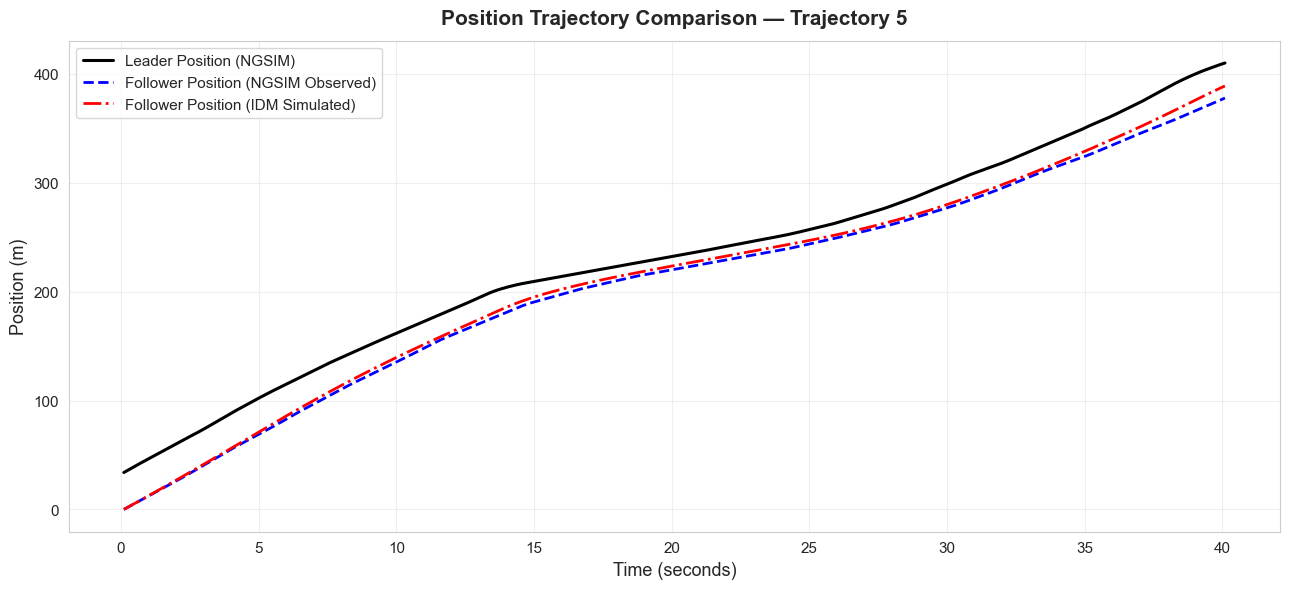

In [45]:
# ── Bonus Plot: Position Trajectory Comparison ────────────────────────────
f_pos = data_subset['follower_position(m)'].values

plt.figure(figsize=(13, 6))

plt.plot(time_data, leader_position,
         color='black', linewidth=2.2, label='Leader Position (NGSIM)')
plt.plot(time_data, f_pos,
         color='blue', linewidth=2.0, linestyle='--',
         label='Follower Position (NGSIM Observed)')
plt.plot(time_data, sim_position,
         color='red', linewidth=2.0, linestyle='-.',
         label='Follower Position (IDM Simulated)')

plt.title(f'Position Trajectory Comparison — Trajectory {TRAJECTORY}',
          fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Time (seconds)', fontsize=13)
plt.ylabel('Position (m)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
